In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

import seaborn as sns

import plotly as py
import plotly.graph_objs as go

from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Create a dataset with 3 features and 400 samples
X, y = make_blobs(n_samples=400, n_features=3, centers=4, random_state=42)

# Display the shape of the dataset
print("Feature Matrix (X) shape:", X.shape)
print("Target Labels (y) shape:", y.shape)

Feature Matrix (X) shape: (400, 3)
Target Labels (y) shape: (400,)


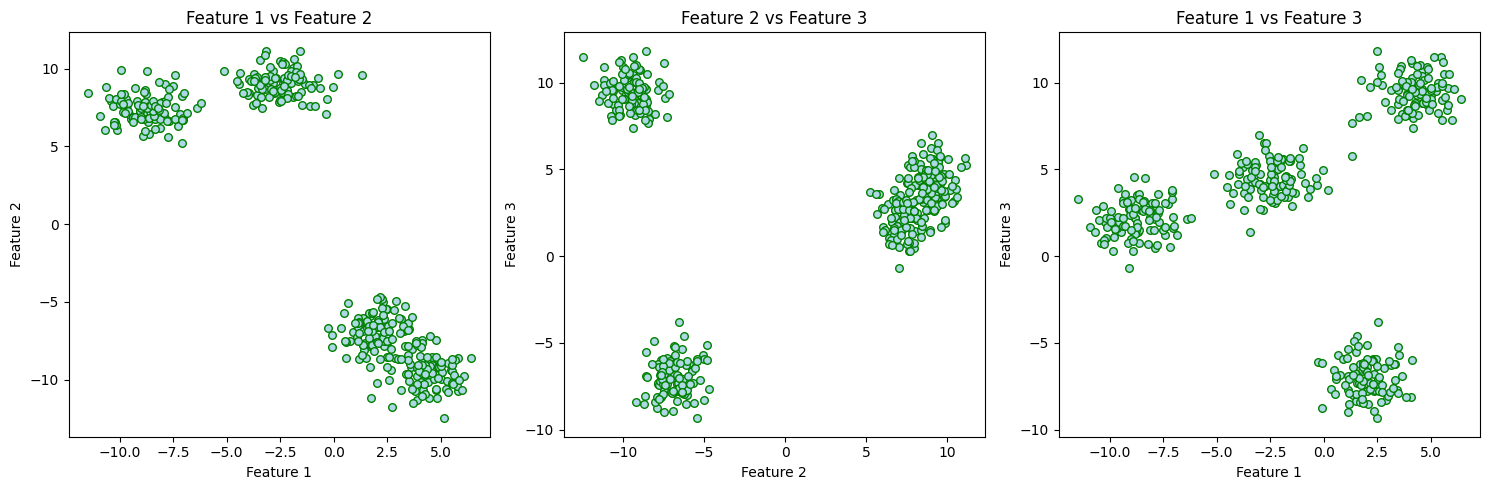

In [3]:
import matplotlib.pyplot as plt

# Plot all feature pairs
plt.figure(figsize=(15, 5))

# Plot feature1 vs feature2
plt.subplot(1, 3, 1)
plt.scatter(X[:, 0], X[:, 1], color='lightblue', s=30, edgecolor='green')
plt.title("Feature 1 vs Feature 2")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# Plot feature2 vs feature3
plt.subplot(1, 3, 2)
plt.scatter(X[:, 1], X[:, 2], color='lightblue', s=30, edgecolor='green')
plt.title("Feature 2 vs Feature 3")
plt.xlabel("Feature 2")
plt.ylabel("Feature 3")

# Plot feature1 vs feature3
plt.subplot(1, 3, 3)
plt.scatter(X[:, 0], X[:, 2], color='lightblue', s=30, edgecolor='green')
plt.title("Feature 1 vs Feature 3")
plt.xlabel("Feature 1")
plt.ylabel("Feature 3")

plt.tight_layout()
plt.show()

In [4]:
#Finding the closest centroind function

def find_closest_centroids(X, centroids):
    """
    Computes the centroid memberships for every example
    
    Args:
        X (ndarray): (m, n) Input values      
        centroids (ndarray): (K, n) centroids
    
    Returns:
        idx (array_like): (m,) closest centroids
    
    """

    # Set K
    K = centroids.shape[0]

    # Centroid assignment array
    idx = np.zeros(X.shape[0], dtype=int)

    # Finding the closest centroid
    for i in range(X.shape[0]):
        distances = [] 
        for j in range(K):
            distance = 0
            for d in range(len(X[i])):
                distance += (X[i][d] - centroids[j][d]) ** 2
            distance = distance ** 0.5 
            distances.append(distance)
        idx[i] = distances.index(min(distances))


    # # Using NumPy
    # for i in range(X.shape[0]):
    #     distance = [] 
    #     for j in range(K):
    #         norm_ij = np.linalg.norm(X[i] - centroids[j]) 
    #         distance.append(norm_ij)
    #     idx[i] = np.argmin(distance)
    
    return idx

In [5]:
def compute_centroids(X, idx, K):
    """
    Returns the new centroids by computing the means of the 
    data points assigned to each centroid.
    
    Args:
        X (ndarray):   (m, n) Data points
        idx (ndarray): (m,) Array containing index of closest centroid for each 
                       example in X. Concretely, idx[i] contains the index of 
                       the centroid closest to example i
        K (int):       number of centroids
    
    Returns:
        centroids (ndarray): (K, n) New centroids computed
    """
    
    # Useful variables
    m, n = X.shape
    
    # Centroid array
    centroids = np.zeros((K, n))
    
    # Calculating new centroids
    for k in range(K):
        points = X[idx == k]
        centroids[k] = np.mean(points, axis = 0)
    
    return centroids

In [6]:
def compute_cost(X, centroids, idx):
    """
    Computes the cost (sum of squared distances) for the current clustering.
    
    Args:
        X (ndarray): Data points (m, n)
        centroids (ndarray): Centroids (K, n)
        idx (ndarray): Index of the closest centroid for each data point
        
    Returns:
        float: Total cost
    """
    cost = 0
    for i in range(X.shape[0]):
        cost += np.sum((X[i] - centroids[idx[i]]) ** 2)
    return cost

In [7]:
def run_kMeans(X, initial_centroids, max_iters=10, plot_progress=False, num_runs=30):
    """
    Runs the K-Means algorithm multiple times and selects the best result.

    Args:
        X (ndarray): Data points (m, n)
        initial_centroids (ndarray): Initial centroids (K, n)
        max_iters (int): Maximum number of iterations per run
        plot_progress (bool): Whether to plot progress
        num_runs (int): Number of independent runs of K-Means

    Returns:
        best_centroids (ndarray): Final centroids with the lowest cost
        best_idx (ndarray): Cluster assignments for the best centroids
        min_cost (float): Minimum cost achieved across all runs
    """
    best_centroids = None
    best_idx = None
    min_cost = float('inf')

    for run in range(num_runs):
        # Initialize centroids randomly for each run
        centroids = kMeans_init_centroids(X, initial_centroids.shape[0])

        # Run K-Means
        for _ in range(max_iters):
            idx = find_closest_centroids(X, centroids)
            centroids = compute_centroids(X, idx, centroids.shape[0])

        # Compute the cost for this run
        cost = compute_cost(X, centroids, idx)

        # Update the best result if this run has a lower cost
        if cost < min_cost:
            min_cost = cost
            best_centroids = centroids
            best_idx = idx

    # Plot the best result if requested
    if plot_progress:
        plt.scatter(X[:, 0], X[:, 1], c=best_idx, cmap='viridis', marker='o', alpha=0.5)
        plt.scatter(best_centroids[:, 0], best_centroids[:, 1], color='red', marker='x', s=100, label='Centroids')
        plt.title(f"Best K-Means Clustering (Cost: {min_cost:.2f})")
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.legend()
        plt.show()

    return best_centroids, best_idx, min_cost

In [8]:
def kMeans_init_centroids(X, K):
    """
    This function initializes K centroids that are to be 
    used in K-Means on the dataset X
    
    Args:
        X (ndarray): Data points 
        K (int):     number of centroids/clusters
    
    Returns:
        centroids (ndarray): Initialized centroids
    """
    
    # Randomly reorder the indices of examples
    randidx = np.random.permutation(X.shape[0])
    
    # Take the first K examples as centroids
    centroids = X[randidx[:K]]
    
    return centroids

In [9]:
def choose_optimal_k(X, max_k=10):
    """
    Determines the optimal number of clusters using the Elbow Method.

    Args:
        X (ndarray): Data points (m, n)
        max_k (int): Maximum number of clusters to consider

    Returns:
        None (Plots the Elbow Method graph)
    """
    wcss = []  # List to store within-cluster sum of squares for each K

    for k in range(1, max_k + 1):
        # Initialize centroids
        initial_centroids = kMeans_init_centroids(X, k)
        
        # Run K-Means
        centroids, idx, _ = run_kMeans(X, initial_centroids, max_iters=10, plot_progress=False)
        
        # Compute WCSS for current K
        total_wcss = 0
        for i in range(k):
            # Get points assigned to the current centroid
            points = X[idx == i]  # Correct way to filter points for cluster `i`
            centroid = centroids[i]
            total_wcss += ((points - centroid) ** 2).sum()  # Sum of squared distances
        
        wcss.append(total_wcss)

    # Plot the Elbow Method graph
    plt.figure(figsize=(8, 6))
    plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--', color='b')
    plt.title("Elbow Method for Optimal K")
    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
    plt.grid(True)
    plt.show()

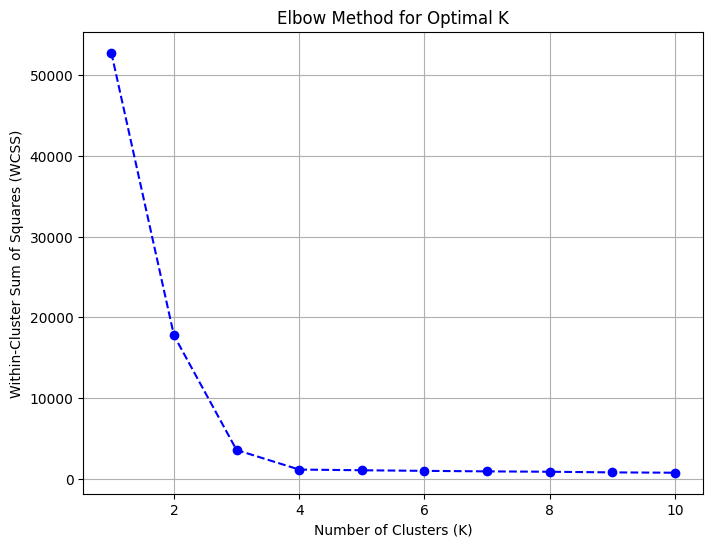

In [10]:
# Determine the optimal number of clusters using the Elbow Method
choose_optimal_k(X, max_k=10)

Shape of X_2D: (400, 2)


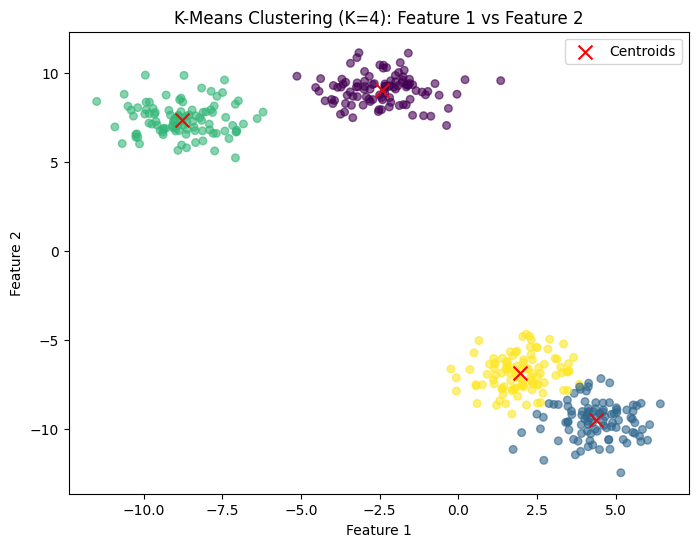

In [11]:
# Use only Feature 1 and Feature 2 for clustering
X_2D = X[:, :2]  # Select Feature 1 and Feature 2

# Initialize centroids for K = 4
K = 4
initial_centroids = kMeans_init_centroids(X_2D, K)

# Check the shape of X_2D to make sure it has two features
print("Shape of X_2D:", X_2D.shape)

# Run K-Means for K = 4
centroids, idx, _ = run_kMeans(X_2D, initial_centroids, max_iters=10, plot_progress=False)

# Visualize the results
plt.figure(figsize=(8, 6))

# Plot data points colored by their assigned cluster
plt.scatter(X_2D[:, 0], X_2D[:, 1], c=idx, cmap='viridis', s=30, alpha=0.6)

# Plot centroids
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=100, label='Centroids')

# Add labels and legend
plt.title("K-Means Clustering (K=4): Feature 1 vs Feature 2")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

Shape of X_2D: (400, 2)


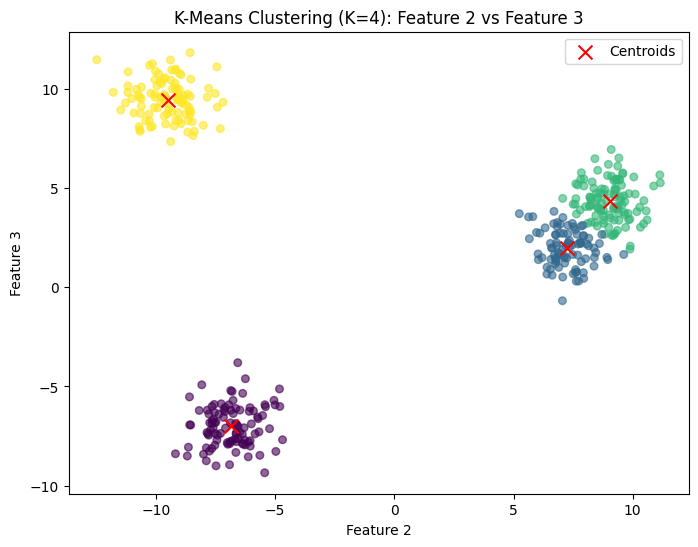

In [12]:
# Use only Feature 2 and Feature 3 for clustering (X[:, 1:] gives features 2 and 3)
X_2D = X[:, 1:]  # Select Feature 2 and Feature 3

# Initialize centroids for K = 4
K = 4
initial_centroids = kMeans_init_centroids(X_2D, K)

# Check the shape of X_2D to make sure it has two features
print("Shape of X_2D:", X_2D.shape)

# Run K-Means for K = 4
centroids, idx, _ = run_kMeans(X_2D, initial_centroids, max_iters=10, plot_progress=False)

# Visualize the results
plt.figure(figsize=(8, 6))

# Plot data points colored by their assigned cluster
plt.scatter(X_2D[:, 0], X_2D[:, 1], c=idx, cmap='viridis', s=30, alpha=0.6)

# Plot centroids
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=100, label='Centroids')

# Add labels and legend
plt.title("K-Means Clustering (K=4): Feature 2 vs Feature 3")
plt.xlabel("Feature 2")
plt.ylabel("Feature 3")
plt.legend()
plt.show()

Shape of X_2D: (400, 2)


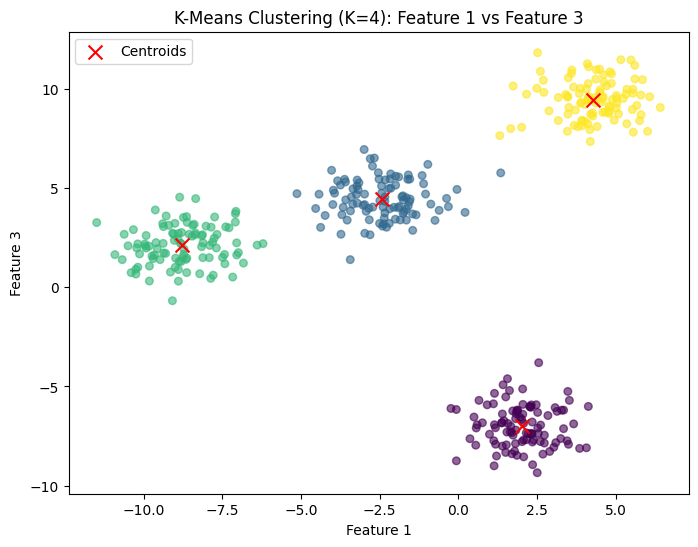

In [13]:
# Use only Feature 1 and Feature 3 for clustering
X_2D = X[:, [0, 2]]  # Select Feature 1 and Feature 3

# Initialize centroids for K = 4
K = 4
initial_centroids = kMeans_init_centroids(X_2D, K)

# Check the shape of X_2D to make sure it has two features
print("Shape of X_2D:", X_2D.shape)

# Run K-Means for K = 4
centroids, idx, _ = run_kMeans(X_2D, initial_centroids, max_iters=10, plot_progress=False)

# Visualize the results
plt.figure(figsize=(8, 6))

# Plot data points colored by their assigned cluster
plt.scatter(X_2D[:, 0], X_2D[:, 1], c=idx, cmap='viridis', s=30, alpha=0.6)

# Plot centroids
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=100, label='Centroids')

# Add labels and legend
plt.title("K-Means Clustering (K=4): Feature 1 vs Feature 3")
plt.xlabel("Feature 1")
plt.ylabel("Feature 3")
plt.legend()
plt.show()

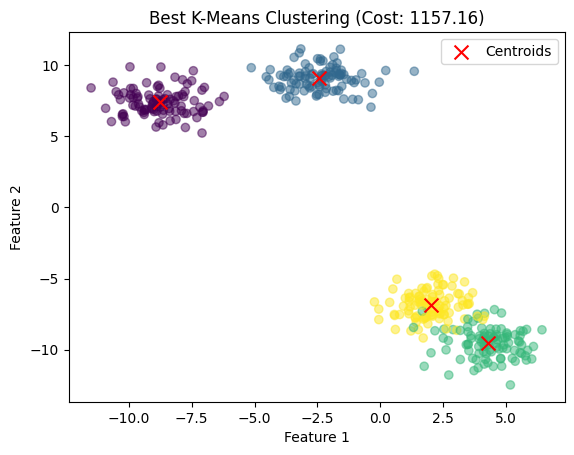

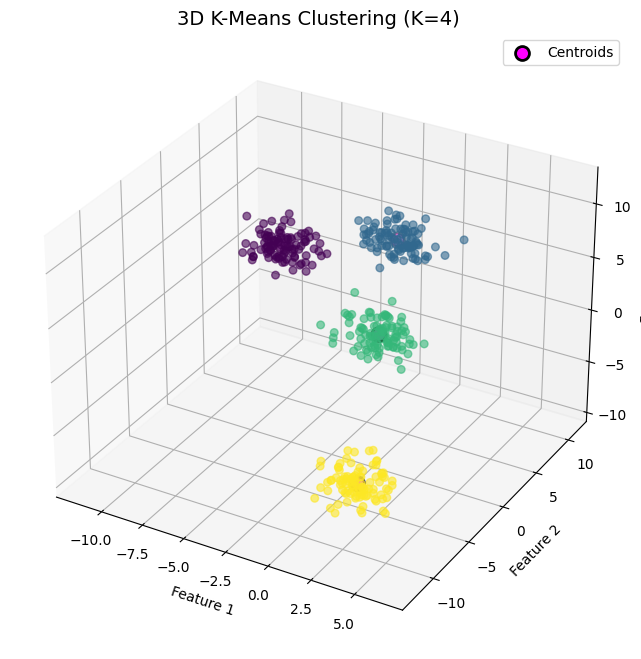

In [14]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Initialize centroids for K = 4
K = 4
initial_centroids = kMeans_init_centroids(X, K)

# Run K-Means for K = 4 with progress visualization
centroids, idx, _ = run_kMeans(X, initial_centroids, max_iters=10, plot_progress=True)

# 3D Plot for Clustering
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot data points color-coded by cluster assignments
sc = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=idx, cmap='viridis', s=30, alpha=0.6)

# Plot centroids
ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], c='magenta', marker='o', s=100, label='Centroids', edgecolor='black', linewidth=2)

# Add labels, legend, and title
ax.set_title("3D K-Means Clustering (K=4)", fontsize=14)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Feature 3")
plt.legend()

# Enable interactive mode for rotatability
plt.show(block=True)  # This keeps the plot open and interactive

In [15]:
df = pd.read_csv("/kaggle/input/kmeans-clustering-for-customer-data/segmented_customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,4


In [16]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'cluster'],
      dtype='object')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
 5   cluster                 200 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 9.5+ KB


In [18]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),cluster
count,200.000000,200.000000,200.000000,200.000000,200.00000
mean,100.500000,38.850000,60.560000,50.200000,2.24500
std,57.879185,13.969007,26.264721,25.823522,1.81423
min,1.000000,18.000000,15.000000,1.000000,0.00000
25%,50.750000,28.750000,41.500000,34.750000,1.00000
50%,100.500000,36.000000,61.500000,50.000000,2.00000
75%,150.250000,49.000000,78.000000,73.000000,4.00000
max,200.000000,70.000000,137.000000,99.000000,5.00000


In [19]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
cluster                   0
dtype: int64

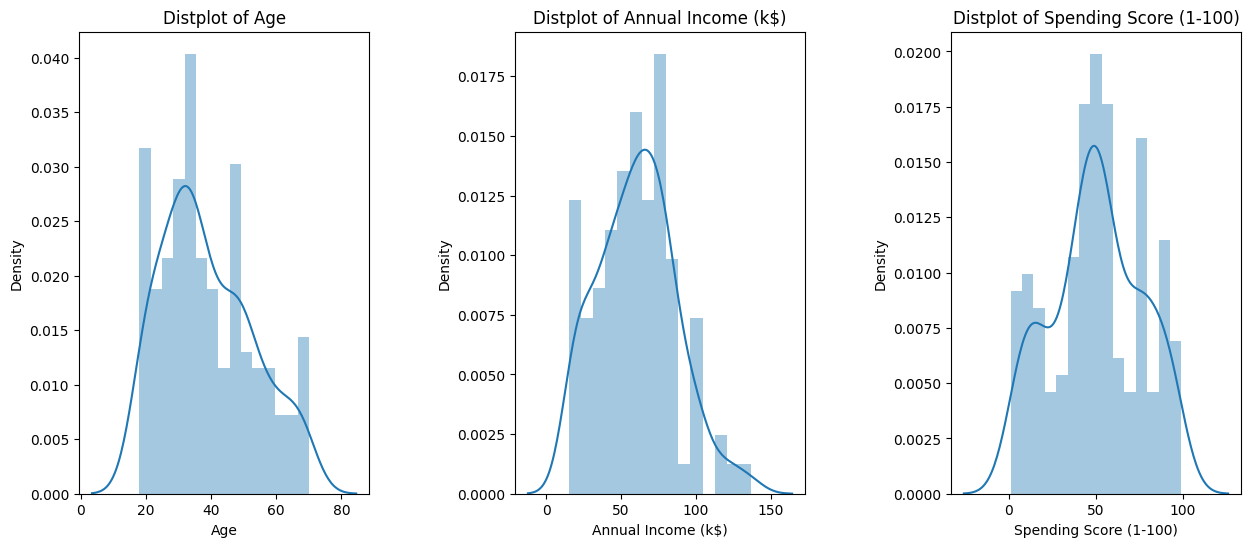

In [20]:
plt.figure(1 , figsize = (15 , 6))
n = 0 
for x in ['Age' , 'Annual Income (k$)' , 'Spending Score (1-100)']:
    n += 1
    plt.subplot(1 , 3 , n)
    plt.subplots_adjust(hspace = 0.5 , wspace = 0.5)
    sns.distplot(df[x] , bins = 15)
    plt.title('Distplot of {}'.format(x))
plt.show()

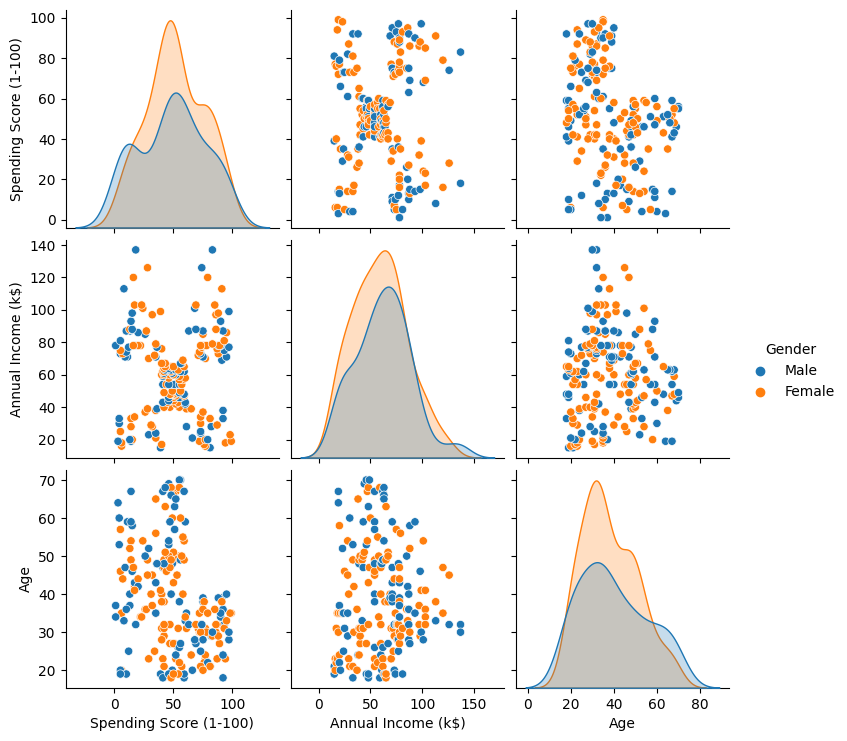

In [21]:
sns.pairplot(df, vars = ['Spending Score (1-100)', 'Annual Income (k$)', 'Age'], hue = "Gender")

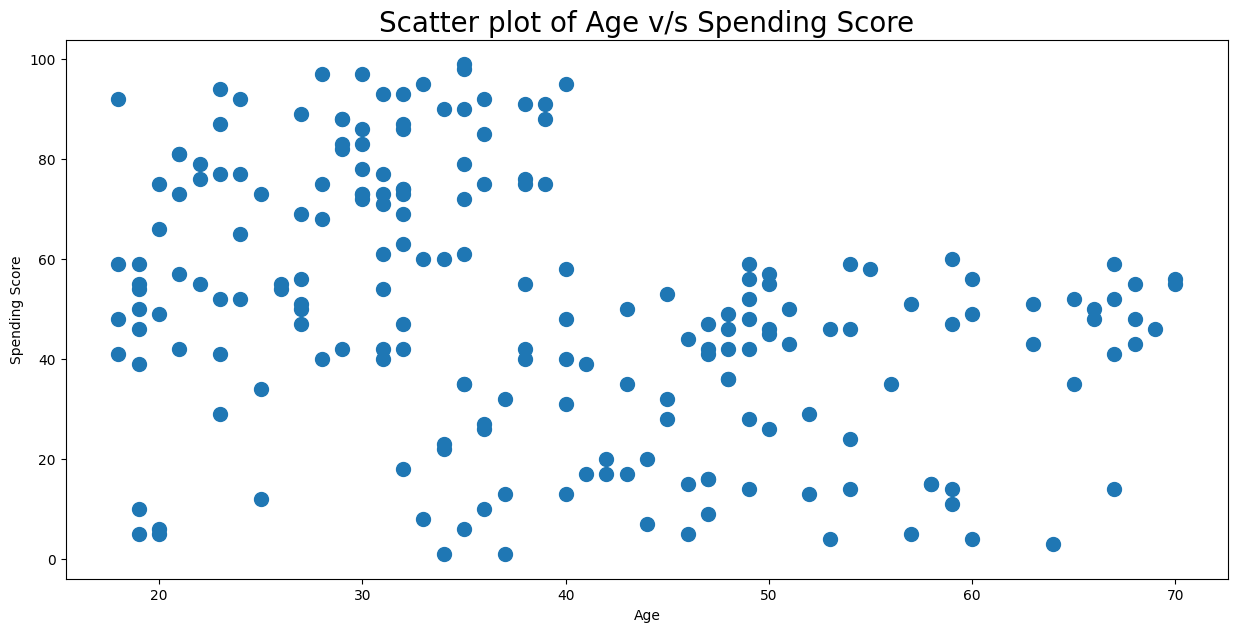

In [22]:
# 2D Clustering based on Age and Spending Score

plt.figure(1 , figsize = (15 , 7))
plt.title('Scatter plot of Age v/s Spending Score', fontsize = 20)
plt.xlabel('Age')
plt.ylabel('Spending Score')
plt.scatter( x = 'Age', y = 'Spending Score (1-100)', data = df, s = 100)
plt.show()

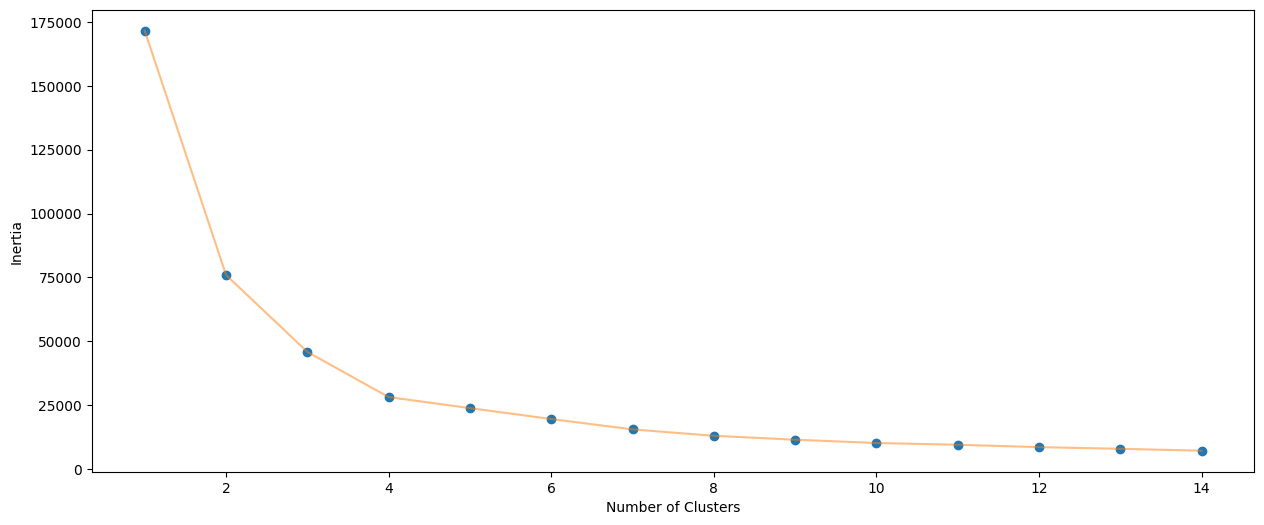

In [23]:
# Deciding K

X1 = df[['Age' , 'Spending Score (1-100)']].iloc[: , :].values
inertia = []
for n in range(1 , 15):
    algorithm = (KMeans(n_clusters = n ,init='k-means++', n_init = 10 ,max_iter=300, 
                        tol=0.0001,  random_state= 111  , algorithm='elkan') )
    algorithm.fit(X1)
    inertia.append(algorithm.inertia_)

plt.figure(1 , figsize = (15 ,6))
plt.plot(np.arange(1 , 15) , inertia , 'o')
plt.plot(np.arange(1 , 15) , inertia , '-' , alpha = 0.5)
plt.xlabel('Number of Clusters') , plt.ylabel('Inertia')
plt.show()

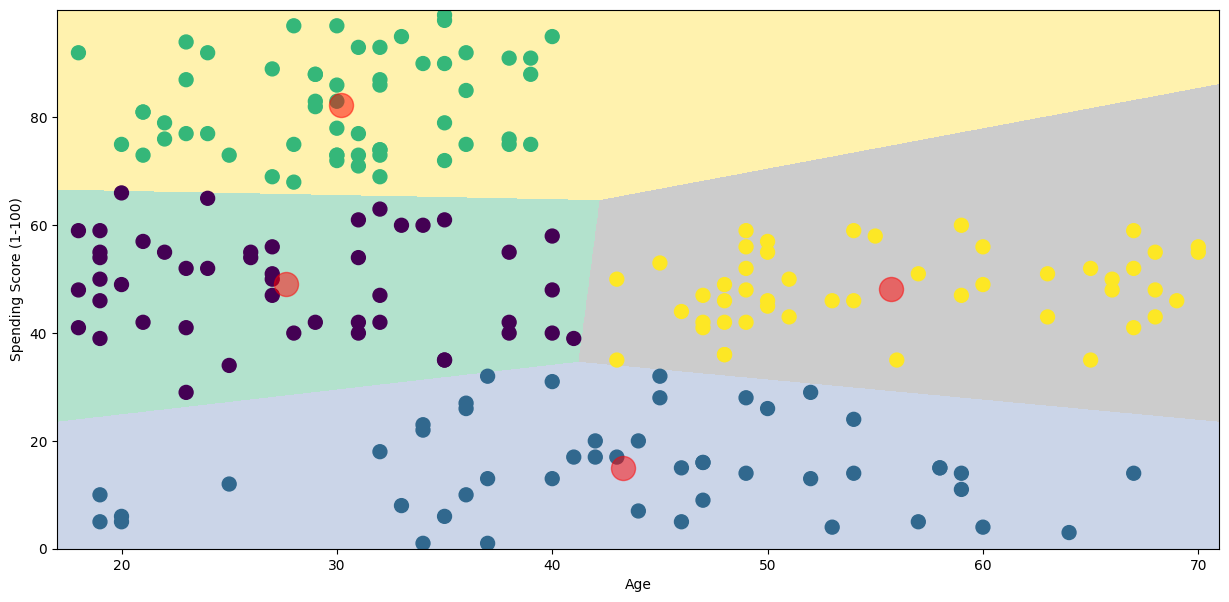

In [24]:
# K = 4

algorithm = (KMeans(n_clusters = 4 ,init='k-means++', n_init = 10 ,max_iter=300, 
                        tol=0.0001,  random_state= 111  , algorithm='elkan') )
algorithm.fit(X1)
labels1 = algorithm.labels_
centroids1 = algorithm.cluster_centers_

h = 0.02
x_min, x_max = X1[:, 0].min() - 1, X1[:, 0].max() + 1
y_min, y_max = X1[:, 1].min() - 1, X1[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = algorithm.predict(np.c_[xx.ravel(), yy.ravel()]) 

plt.figure(1 , figsize = (15 , 7) )
plt.clf()
Z = Z.reshape(xx.shape)
plt.imshow(Z , interpolation='nearest', 
           extent=(xx.min(), xx.max(), yy.min(), yy.max()),
           cmap = plt.cm.Pastel2, aspect = 'auto', origin='lower')

plt.scatter( x = 'Age', y = 'Spending Score (1-100)', data = df, c = labels1, s = 100)
plt.scatter(x = centroids1[: , 0] , y =  centroids1[: , 1] , s = 300 , c = 'red' , alpha = 0.5)
plt.ylabel('Spending Score (1-100)') , plt.xlabel('Age')
plt.show()

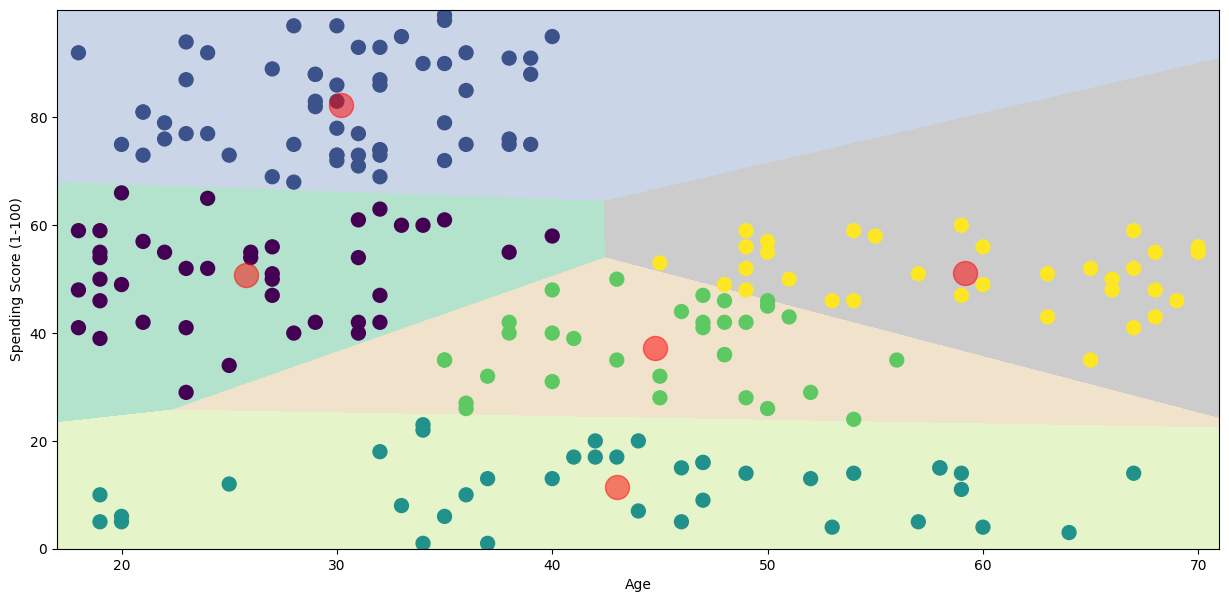

In [25]:
# K = 5

algorithm = (KMeans(n_clusters = 5, init='k-means++', n_init = 10, max_iter=300, 
                        tol=0.0001, random_state= 111 , algorithm='elkan'))
algorithm.fit(X1)
labels1 = algorithm.labels_
centroids1 = algorithm.cluster_centers_

h = 0.02
x_min, x_max = X1[:, 0].min() - 1, X1[:, 0].max() + 1
y_min, y_max = X1[:, 1].min() - 1, X1[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = algorithm.predict(np.c_[xx.ravel(), yy.ravel()]) 

plt.figure(1 , figsize = (15 , 7) )
plt.clf()
Z = Z.reshape(xx.shape)
plt.imshow(Z , interpolation='nearest', 
           extent=(xx.min(), xx.max(), yy.min(), yy.max()),
           cmap = plt.cm.Pastel2, aspect = 'auto', origin='lower')

plt.scatter( x = 'Age', y = 'Spending Score (1-100)', data = df, c = labels1, s = 100)
plt.scatter(x = centroids1[: , 0] , y =  centroids1[: , 1] , s = 300 , c = 'red' , alpha = 0.5)
plt.ylabel('Spending Score (1-100)') , plt.xlabel('Age')
plt.show()

In [26]:
# 2D Clustering based on Annual Income and Spending Score

X2 = df[['Annual Income (k$)' , 'Spending Score (1-100)']].iloc[: , :].values
inertia = []
for n in range(1 , 11):
    algorithm = (KMeans(n_clusters = n ,init='k-means++', n_init = 10 ,max_iter=300, 
                        tol=0.0001,  random_state= 111  , algorithm='elkan') )
    algorithm.fit(X2)
    inertia.append(algorithm.inertia_)

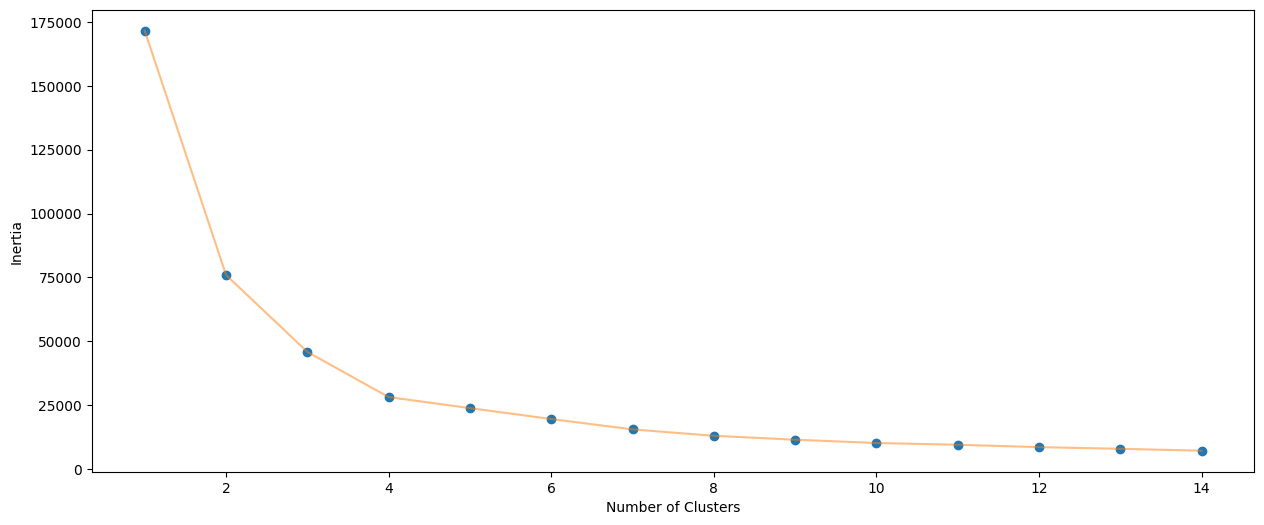

In [27]:
# Deciding K

X1 = df[['Age' , 'Spending Score (1-100)']].iloc[: , :].values
inertia = []
for n in range(1 , 15):
    algorithm = (KMeans(n_clusters = n ,init='k-means++', n_init = 10 ,max_iter=300, 
                        tol=0.0001,  random_state= 111  , algorithm='elkan') )
    algorithm.fit(X1)
    inertia.append(algorithm.inertia_)


plt.figure(1 , figsize = (15 ,6))
plt.plot(np.arange(1 , 15) , inertia , 'o')
plt.plot(np.arange(1 , 15) , inertia , '-' , alpha = 0.5)
plt.xlabel('Number of Clusters') , plt.ylabel('Inertia')
plt.show()

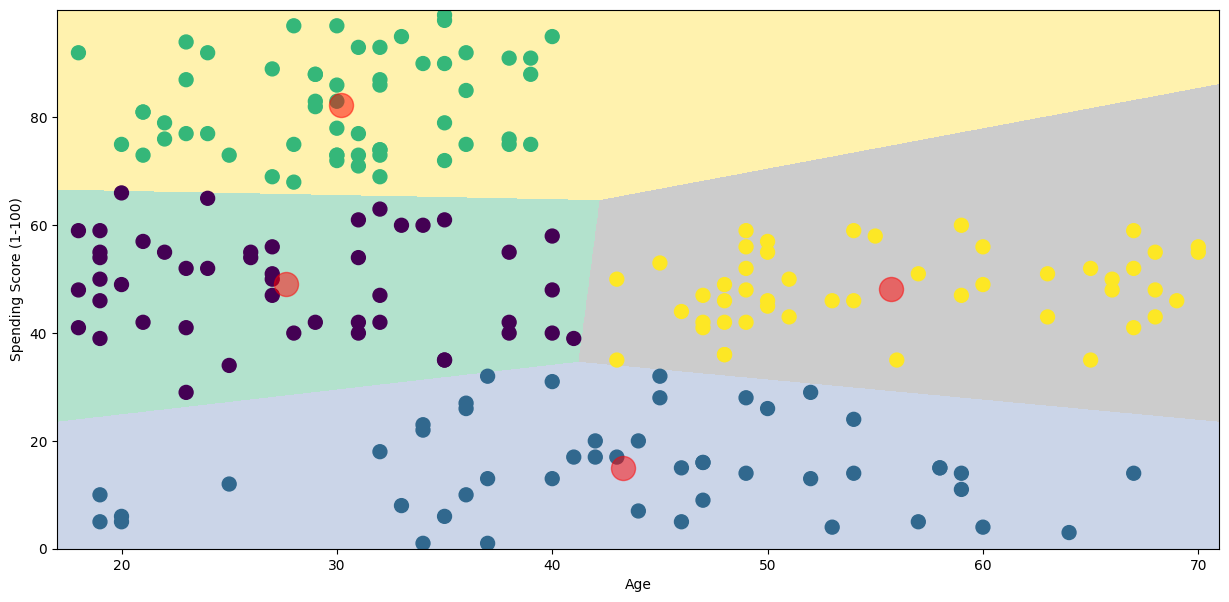

In [28]:
# K = 4

algorithm = (KMeans(n_clusters = 4 ,init='k-means++', n_init = 10 ,max_iter=300, 
                        tol=0.0001,  random_state= 111  , algorithm='elkan') )
algorithm.fit(X1)
labels1 = algorithm.labels_
centroids1 = algorithm.cluster_centers_

h = 0.02
x_min, x_max = X1[:, 0].min() - 1, X1[:, 0].max() + 1
y_min, y_max = X1[:, 1].min() - 1, X1[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = algorithm.predict(np.c_[xx.ravel(), yy.ravel()]) 

plt.figure(1 , figsize = (15 , 7) )
plt.clf()
Z = Z.reshape(xx.shape)
plt.imshow(Z , interpolation='nearest', 
           extent=(xx.min(), xx.max(), yy.min(), yy.max()),
           cmap = plt.cm.Pastel2, aspect = 'auto', origin='lower')

plt.scatter( x = 'Age', y = 'Spending Score (1-100)', data = df, c = labels1, s = 100)
plt.scatter(x = centroids1[: , 0] , y =  centroids1[: , 1] , s = 300 , c = 'red' , alpha = 0.5)
plt.ylabel('Spending Score (1-100)') , plt.xlabel('Age')
plt.show()

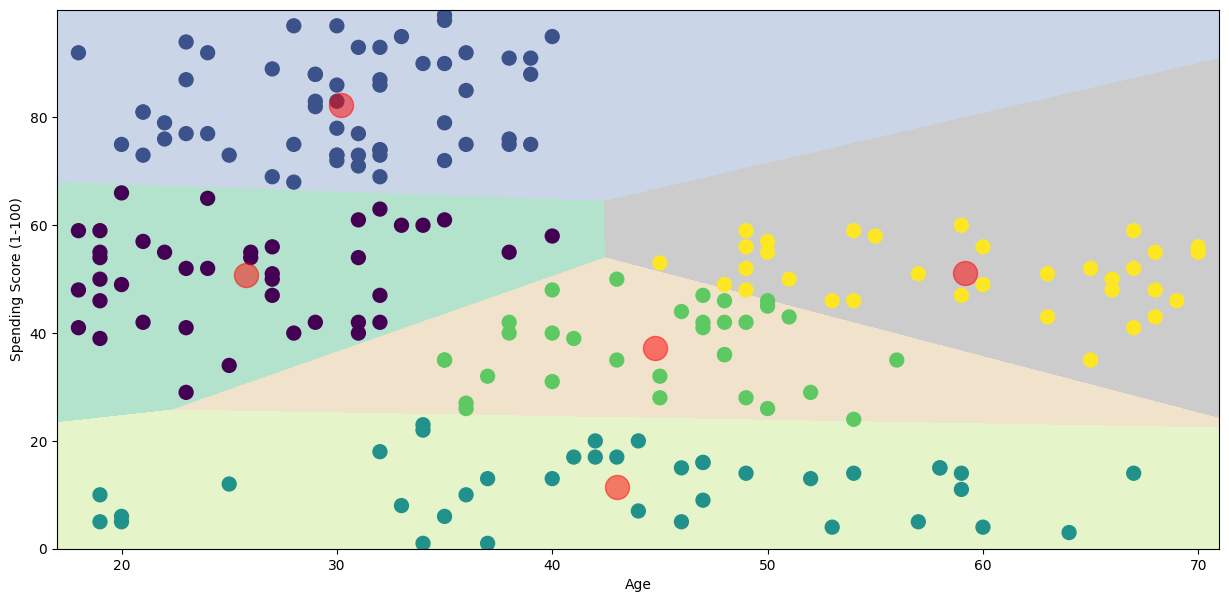

In [29]:
# K = 5

algorithm = (KMeans(n_clusters = 5, init='k-means++', n_init = 10, max_iter=300, 
                        tol=0.0001, random_state= 111 , algorithm='elkan'))
algorithm.fit(X1)
labels1 = algorithm.labels_
centroids1 = algorithm.cluster_centers_

h = 0.02
x_min, x_max = X1[:, 0].min() - 1, X1[:, 0].max() + 1
y_min, y_max = X1[:, 1].min() - 1, X1[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = algorithm.predict(np.c_[xx.ravel(), yy.ravel()])

plt.figure(1 , figsize = (15 , 7) )
plt.clf()
Z = Z.reshape(xx.shape)
plt.imshow(Z , interpolation='nearest', 
           extent=(xx.min(), xx.max(), yy.min(), yy.max()),
           cmap = plt.cm.Pastel2, aspect = 'auto', origin='lower')

plt.scatter( x = 'Age', y = 'Spending Score (1-100)', data = df, c = labels1, s = 100)
plt.scatter(x = centroids1[: , 0] , y =  centroids1[: , 1] , s = 300 , c = 'red' , alpha = 0.5)
plt.ylabel('Spending Score (1-100)') , plt.xlabel('Age')
plt.show()

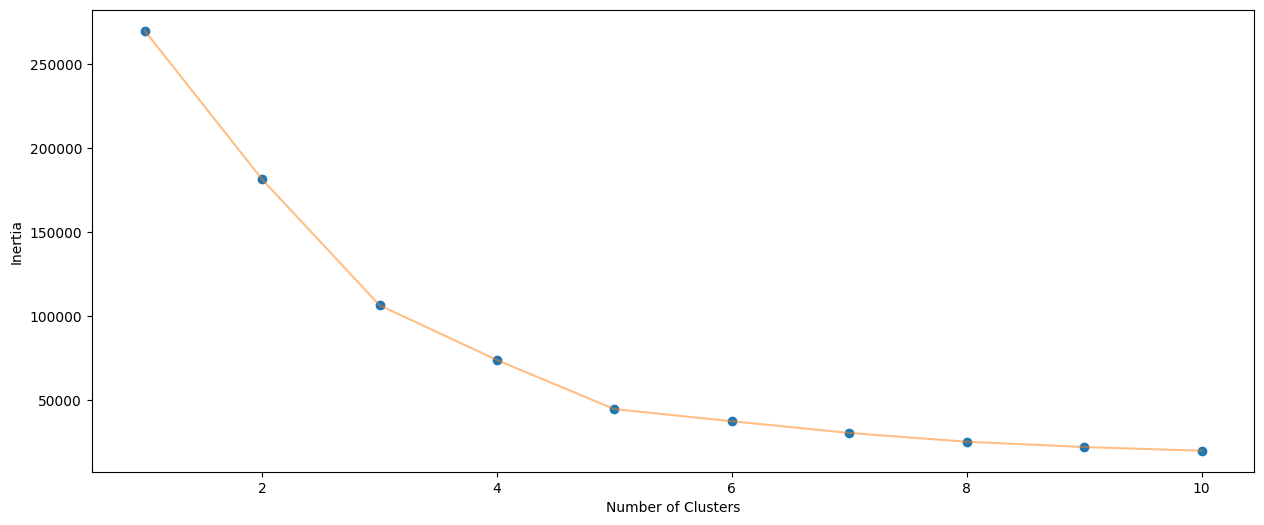

In [30]:
# 2D Clustering based on Annual Income and Spending Score
# Choosing K 

X2 = df[['Annual Income (k$)' , 'Spending Score (1-100)']].iloc[: , :].values
inertia = []
for n in range(1 , 11):
    algorithm = (KMeans(n_clusters = n ,init='k-means++', n_init = 10 ,max_iter=300, 
                        tol=0.0001,  random_state= 111  , algorithm='elkan') )
    algorithm.fit(X2)
    inertia.append(algorithm.inertia_)


plt.figure(1 , figsize = (15 ,6))
plt.plot(np.arange(1 , 11) , inertia , 'o')
plt.plot(np.arange(1 , 11) , inertia , '-' , alpha = 0.5)
plt.xlabel('Number of Clusters') , plt.ylabel('Inertia')
plt.show()

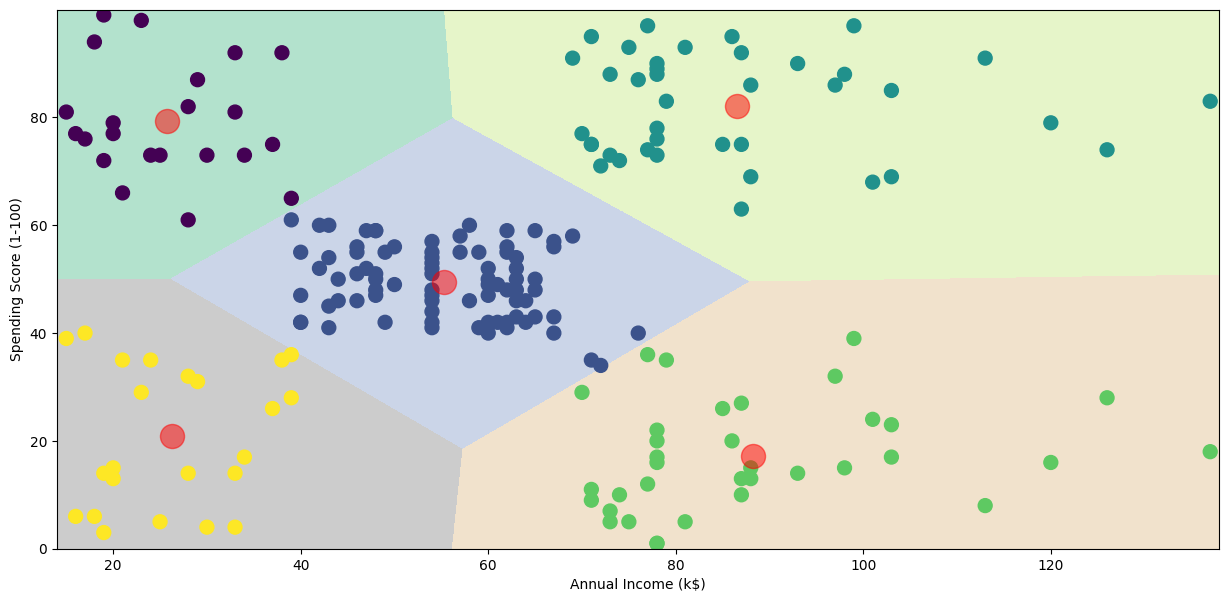

In [31]:
# K = 5

algorithm = (KMeans(n_clusters = 5 ,init='k-means++', n_init = 10 ,max_iter=300, 
                        tol=0.0001,  random_state= 111  , algorithm='elkan') )
algorithm.fit(X2)
labels2 = algorithm.labels_
centroids2 = algorithm.cluster_centers_

h = 0.02
x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z2 = algorithm.predict(np.c_[xx.ravel(), yy.ravel()])

plt.figure(1 , figsize = (15 , 7) )
plt.clf()
Z2 = Z2.reshape(xx.shape)
plt.imshow(Z2 , interpolation='nearest', 
           extent=(xx.min(), xx.max(), yy.min(), yy.max()),
           cmap = plt.cm.Pastel2, aspect = 'auto', origin='lower')

plt.scatter( x = 'Annual Income (k$)' ,y = 'Spending Score (1-100)' , data = df , c = labels2 , 
            s = 100 )
plt.scatter(x = centroids2[: , 0] , y =  centroids2[: , 1] , s = 300 , c = 'red' , alpha = 0.5)
plt.ylabel('Spending Score (1-100)') , plt.xlabel('Annual Income (k$)')
plt.show()

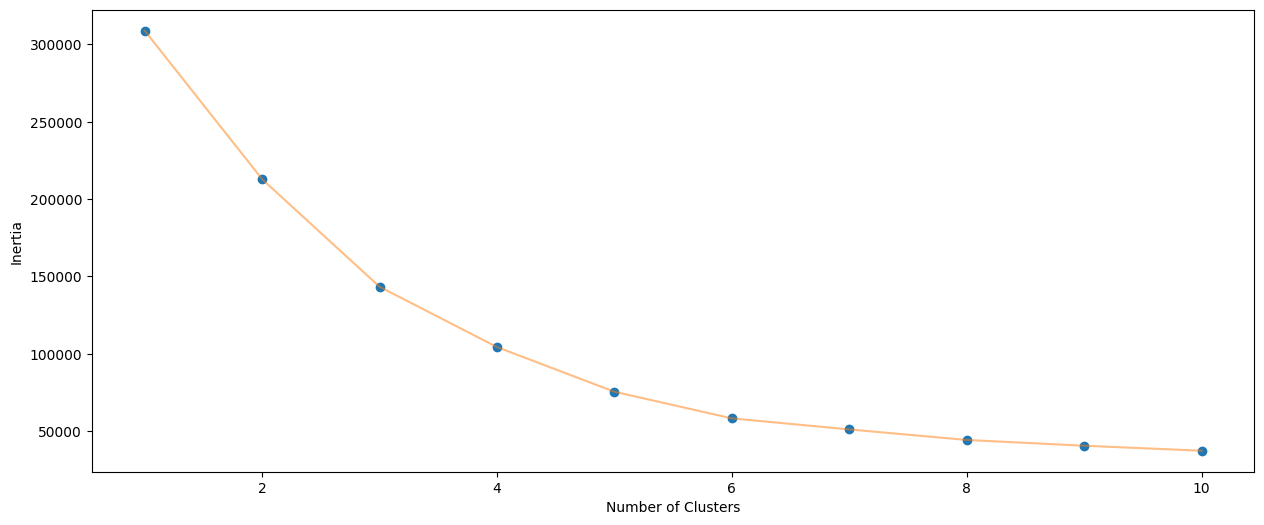

In [32]:
# 3D Clustering Age , Annual Income and Spending Score

X3 = df[['Age' , 'Annual Income (k$)' ,'Spending Score (1-100)']].iloc[: , :].values
inertia = []
for n in range(1 , 11):
    algorithm = (KMeans(n_clusters = n, init='k-means++', n_init = 10, max_iter=300, 
                        tol=0.0001, random_state= 111, algorithm='elkan'))
    algorithm.fit(X3)
    inertia.append(algorithm.inertia_)

plt.figure(1 , figsize = (15 ,6))
plt.plot(np.arange(1 , 11) , inertia , 'o')
plt.plot(np.arange(1 , 11) , inertia , '-' , alpha = 0.5)
plt.xlabel('Number of Clusters') , plt.ylabel('Inertia')
plt.show()

In [33]:
# K = 6

algorithm = (KMeans(n_clusters = 6 ,init='k-means++', n_init = 10 ,max_iter=300, 
                        tol=0.0001,  random_state= 111  , algorithm='elkan') )
algorithm.fit(X3)
labels3 = algorithm.labels_
centroids3 = algorithm.cluster_centers_

y_kmeans = algorithm.fit_predict(X3)
df['cluster'] = pd.DataFrame(y_kmeans)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,5
2,3,Female,20,16,6,4
3,4,Female,23,16,77,5
4,5,Female,31,17,40,4


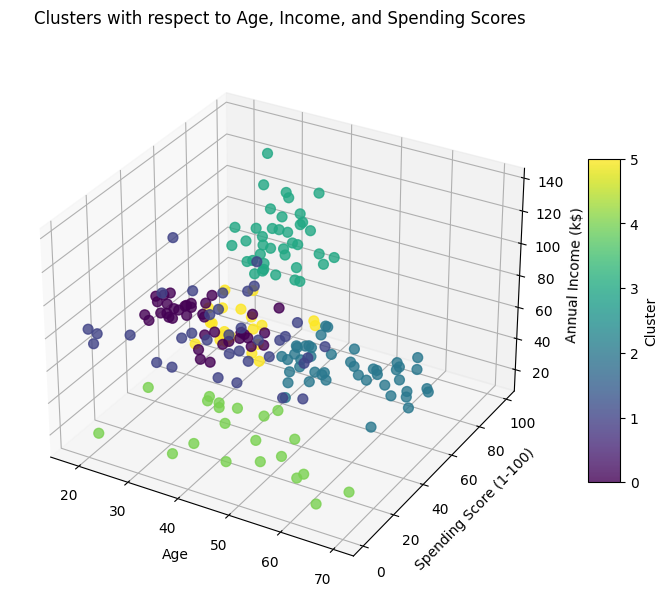

In [34]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with actual df data
scatter = ax.scatter(
    df['Age'],
    df['Spending Score (1-100)'],
    df['Annual Income (k$)'],
    c=df['cluster'],  # Color by cluster
    cmap='viridis',   # Color map
    s=50,             # Marker size
    alpha=0.8         # Transparency
)

# Add labels
ax.set_title('Clusters with respect to Age, Income, and Spending Scores', pad=20)
ax.set_xlabel('Age')
ax.set_ylabel('Spending Score (1-100)')
ax.set_zlabel('Annual Income (k$)')

# Add a color bar to show the cluster mapping
color_bar = fig.colorbar(scatter, ax=ax, shrink=0.6, aspect=10)
color_bar.set_label('Cluster')

# Show the plot
plt.show()